In [1]:
from functools import partial


import iris
from iris.experimental.stratify import relevel
from loguru import logger
import numpy as np
import stratify



/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
cubes_c = iris.load('/gws/nopw/j04/kscale/DYAMOND3_data/5km-RAL3/glm/field.pp/apverc.pp/glm.n2560_RAL3p3.apverc_20200120T00.pp')

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/iris/fileformats/rules.py:371: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


In [3]:
cubes_c

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/iris/common/mixin.py:203: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


Mass Fraction Of Cloud Ice Crystals In Air (kg kg-1),time,model_level_number,latitude,longitude
Shape,5,60,3840,5120
Dimension coordinates,,,,
time,x,-,-,-
model_level_number,-,x,-,-
latitude,-,-,x,-
longitude,-,-,-,x
Auxiliary coordinates,,,,
forecast_period,x,-,-,-
level_height,-,x,-,-
sigma,-,x,-,-


In [4]:
clw = cubes_c[3]

In [5]:
cubes_d = iris.load('/gws/nopw/j04/kscale/DYAMOND3_data/5km-RAL3/glm/field.pp/apverd.pp/glm.n2560_RAL3p3.apverd_20200120T00.pp')

In [6]:
cubes_d

[<iris 'Cube' of air_temperature / (K) (time: 5; pressure: 25; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of geopotential_height / (m) (time: 5; pressure: 25; latitude: 3840; longitude: 5120)>,
<iris 'Cube' of relative_humidity / (%) (time: 5; pressure: 25; latitude: 3840; longitude: 5120)>]

In [7]:
p = cubes_c[1]

In [8]:
z = cubes_d[1]

In [35]:
def model_level_to_pressure(cube, p, z):
    logger.debug(f're-level model level to pressure for {cube.name()}')
    cube = cube[-p.shape[0]:]
    assert (p.coord('time').points == cube.coord('time').points).all()

    # Direction of pressure_levels must match that of air_pressure/p.
    # This runs, but it also inverts the 3D fields! Fix by inverting output.
    pressure_levels = z.coord('pressure').points[::-1] * 100  # convert from hPa to Pa.
    interpolator = partial(stratify.interpolate,
                           interpolation=stratify.INTERPOLATE_LINEAR,
                           extrapolation=stratify.EXTRAPOLATE_LINEAR,
                           rising=False)
    new_cube_data = np.zeros((cube.shape[0], len(pressure_levels), cube.shape[2], cube.shape[3]))
    for i in range(cube.shape[0]):
        logger.trace(i)
        regridded_cube = relevel(cube[i], p[i], pressure_levels, interpolator=interpolator)
        # logger.trace(f'regridded_cube.data.sum() {regridded_cube.data.sum()}')
        # Fix 3D fields so that they are the right way round - invert output.
        new_cube_data[i] = regridded_cube.data[::-1]
        #new_cube_data[i] = regridded_cube.data

    coords = [(cube.coord('time'), 0), (z.coord('pressure'), 1), (cube.coord('latitude'), 2),
              (cube.coord('longitude'), 3)]
    new_cube = iris.cube.Cube(new_cube_data,
                              long_name=cube.name(),
                              units=cube.units,
                              dim_coords_and_dims=coords,
                              attributes=cube.attributes)
    logger.trace(new_cube)
    return new_cube

In [10]:
#clw_p = model_level_to_pressure(clw, p, z)

In [11]:
#clw = clw[1:, :, :10, :10]

In [12]:
#p = p[:, :, :10, :10]


In [13]:
#z = z[1:, :, :10, :10]

In [14]:
#clw_p = model_level_to_pressure(clw[1:, :, , p, z)

In [15]:
#clw_p.data.mean(axis=(0, 2, 3))

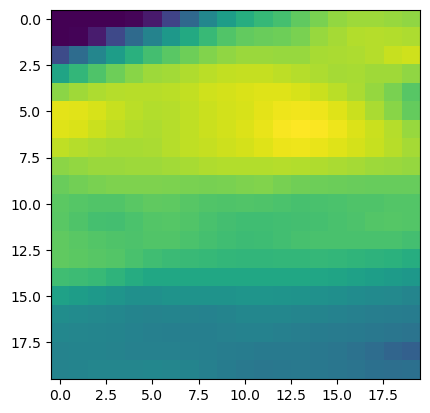

In [20]:
import matplotlib.pyplot as plt
plt.imshow(clw[-1:, :1, 520:540, 1640:1660].data.mean(axis=(0, 1)))

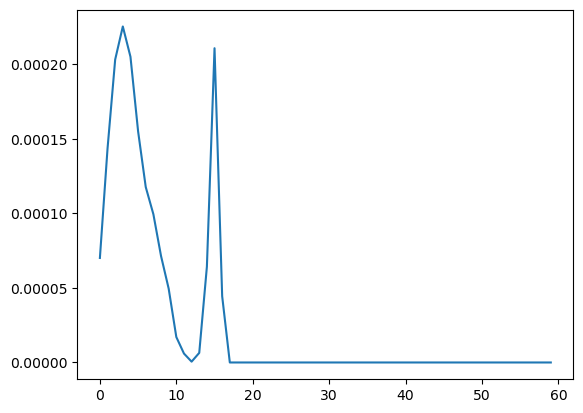

In [22]:
plt.plot(clw[-1:, :, 520:540, 1640:1660].data.mean(axis=(0, 2, 3)))

In [36]:
clw2 = model_level_to_pressure(clw[-1:, :, 520:540, 1640:1660], p[-1:, :, 520:540, 1640:1660], z)


2025-07-28 17:19:16.111 | DEBUG    | __main__:model_level_to_pressure:2 - re-level model level to pressure for mass_fraction_of_cloud_liquid_water_in_air


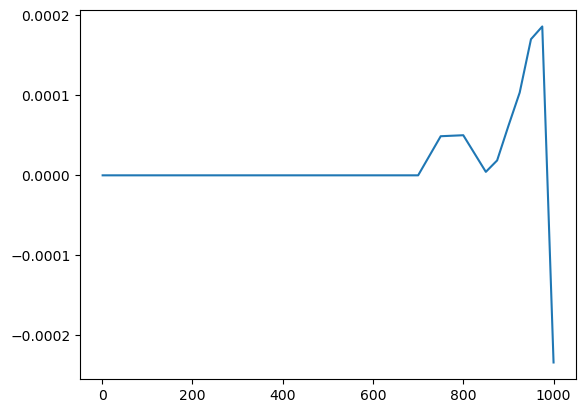

In [38]:
plt.plot(clw2.coord('pressure').points, clw2.data.mean(axis=(0, 2, 3)))